In [2]:
import argparse
import json
import os
import pathlib
import sys
import time

import joblib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import tifffile
from arg_parsing_utils import check_for_missing_args, parse_args
from file_reading import *
from file_reading import read_zstack_image
from notebook_init_utils import bandicoot_check, init_notebook
from skimage.filters import sobel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot/NF1_organoid_data")).resolve(),
    root_dir,
)
patient_list_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve(
    strict=True
)
raw_image_base_dir = pathlib.Path(f"{image_base_dir}/data/").resolve()

In [4]:
subparent_raw_dirs = ["0a.zmax_proj", "0b.middle_slice", "0c.middle_n_slice_max_proj"]
subparent_ic_dirs = [
    "1a.zmax_proj_illum_correction",
    "1b.middle_slice_illum_correction",
    "1c.middle_n_slice_max_proj_illum_correction",
]

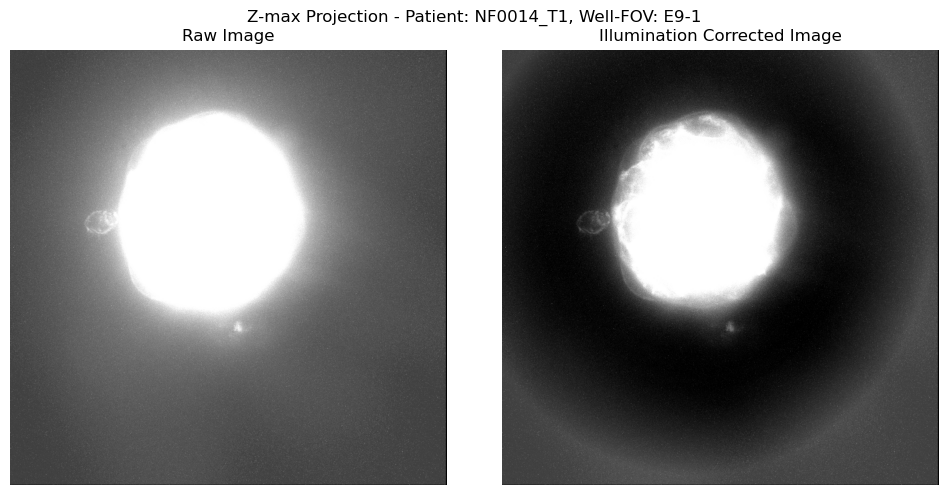

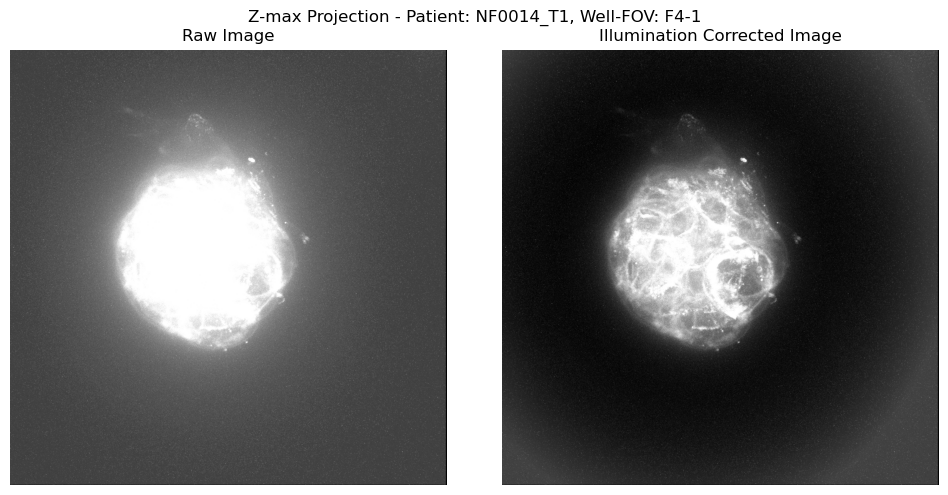

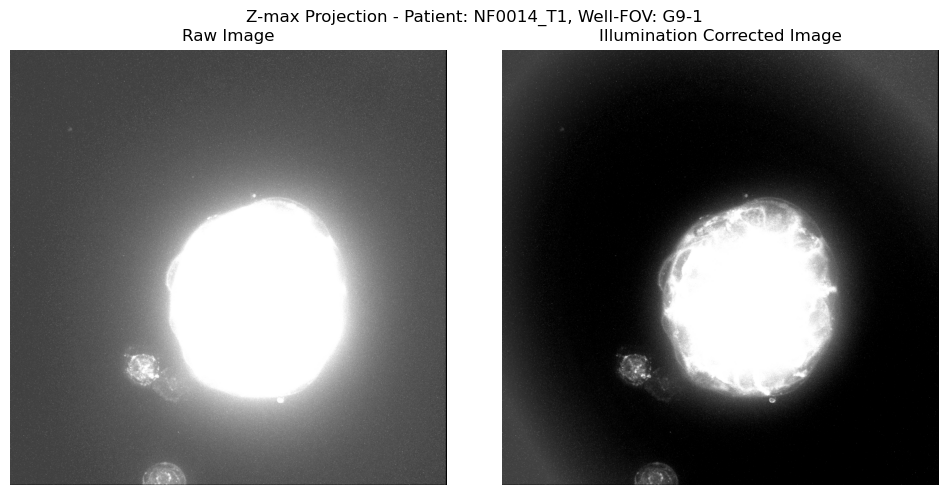

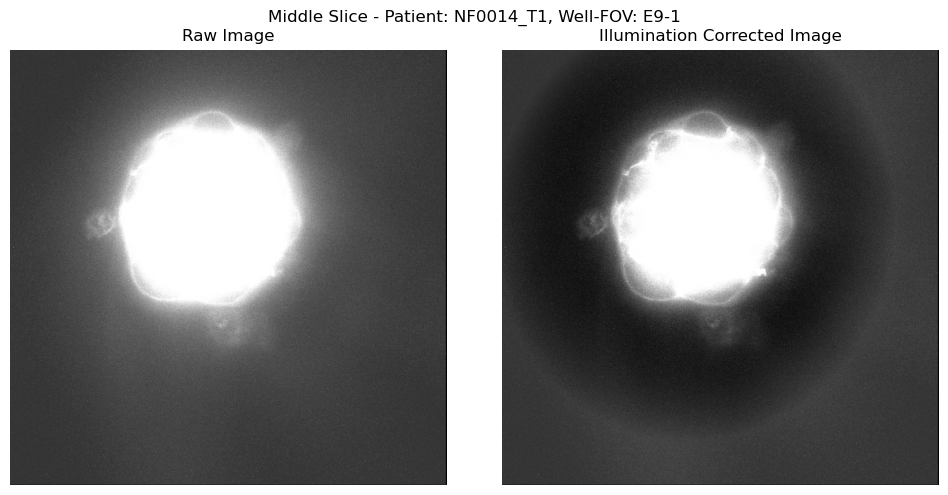

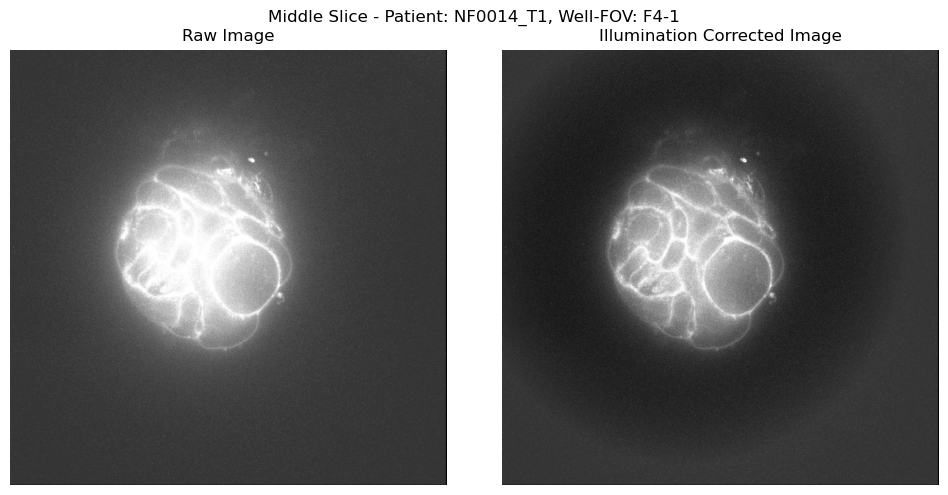

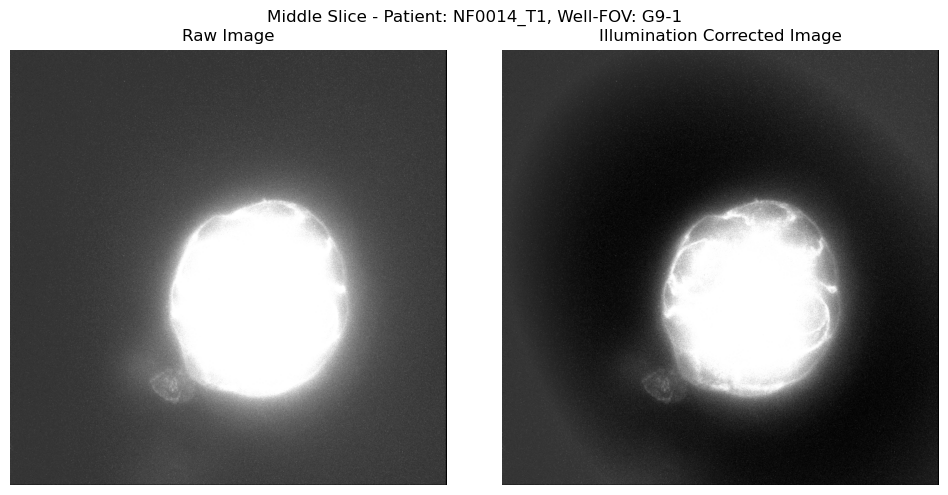

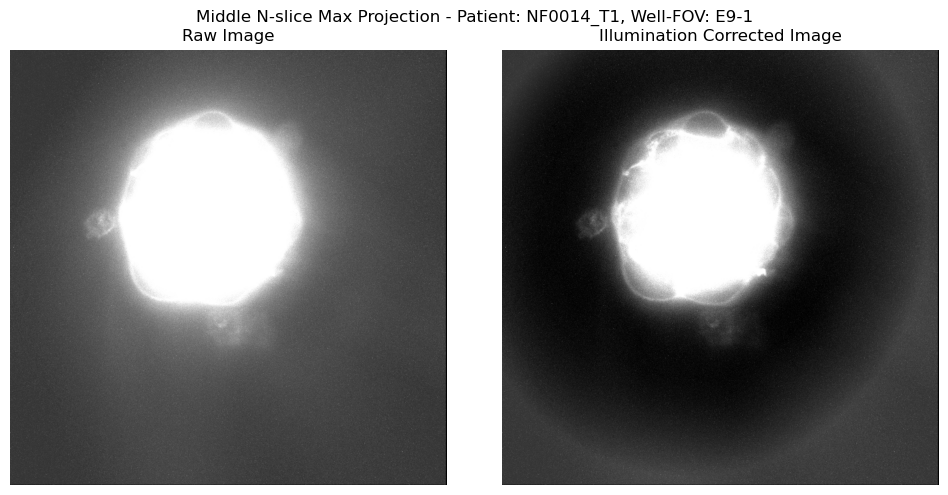

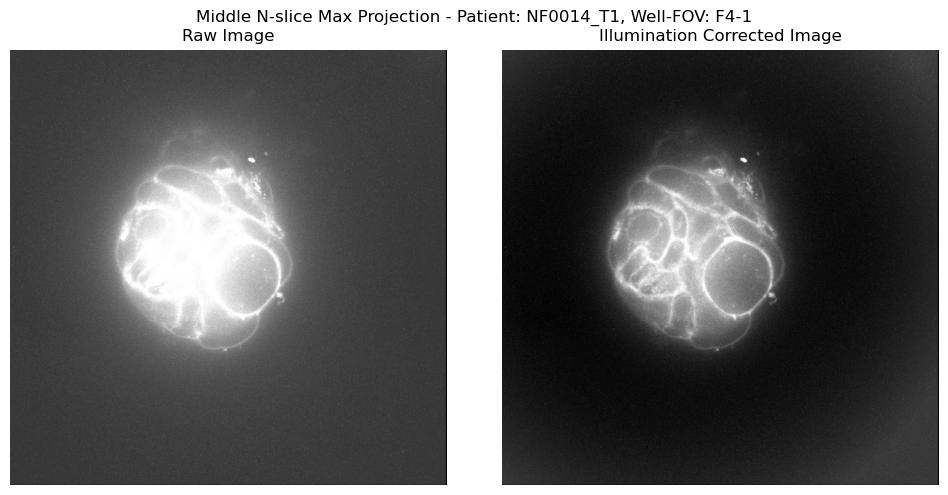

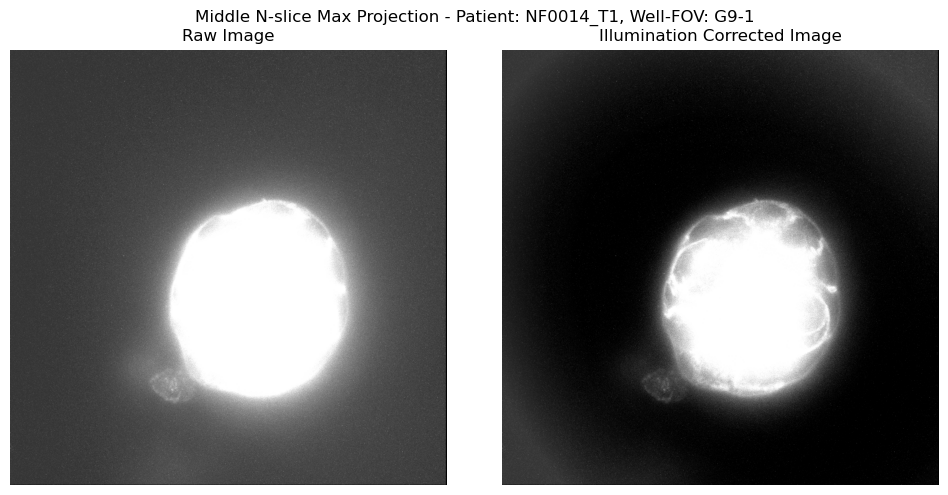

: 

In [ ]:
patient = "NF0014_T1"
patient_well_fovs_to_plot = ["E9-1", "F4-1", "G9-1"]
for subparent_raw_dir, subparent_ic_dir in zip(subparent_raw_dirs, subparent_ic_dirs):
    for well_fov in patient_well_fovs_to_plot:
        raw_image_path = pathlib.Path(
            f"{image_base_dir}/data/{patient}/2D_analysis/{subparent_raw_dir}/{well_fov}/{well_fov}_555.tif"
        ).resolve(strict=True)
        ic_image_path = pathlib.Path(
            f"{image_base_dir}/data/{patient}/2D_analysis/{subparent_ic_dir}/{well_fov}/{well_fov}_555_illumcorrect.tiff"
        ).resolve(strict=True)
        if subparent_raw_dir == "0a.zmax_proj":
            title = f"Z-max Projection - Patient: {patient}, Well-FOV: {well_fov}"
        elif subparent_raw_dir == "0b.middle_slice":
            title = f"Middle Slice - Patient: {patient}, Well-FOV: {well_fov}"
        elif subparent_raw_dir == "0c.middle_n_slice_max_proj":
            title = f"Middle N-slice Max Projection - Patient: {patient}, Well-FOV: {well_fov}"
        raw_image = tifffile.imread(raw_image_path)
        ic_image = tifffile.imread(ic_image_path)
        # clip limits for better visualization
        raw_image = np.clip(raw_image, 0, 5000)
        ic_image = np.clip(ic_image, 0, 5000)
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(raw_image, cmap="gray")
        axes[0].set_title("Raw Image")
        axes[0].axis("off")
        axes[1].imshow(ic_image, cmap="gray")
        axes[1].set_title("Illumination Corrected Image")
        axes[1].axis("off")
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()